In [5]:
import os
os.getcwd()

'd:\\Programming\\labwork\\cv_labexam'

### Arithmetic and Geometric Filters are good for Gaussian noise

In [6]:
import numpy as np
import cv2

img_dir = os.path.join(os.getcwd(), "data", "images", "circuit.png")
img = cv2.imread(img_dir) / 255.0
mean = 0
std = 0.1
noise = np.random.normal(mean, std, img.shape)
noisy_image = img + noise
noisy_image = np.clip(noisy_image, 0, 1)

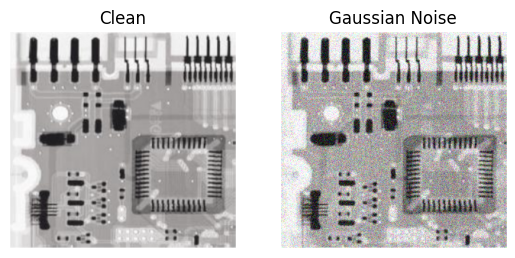

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=1, ncols=2)
axes[0].imshow(img)
axes[0].set_title("Clean")
axes[0].axis("off")
axes[1].imshow(noisy_image)
axes[1].set_title("Gaussian Noise")
axes[1].axis("off")

plt.show()

In [8]:
def arithmetic_mean_filter(image, kernel=3):
    pad = kernel // 2
    padded = np.pad(img, pad, mode='reflect')
    output = np.zeros_like(img, dtype=np.float32)
    H, W, C = image.shape
    for i in range(H):
        for j in range(W):
            region = padded[i:i + kernel, j:j + kernel]
            output[i, j] = np.mean(region)
    return output

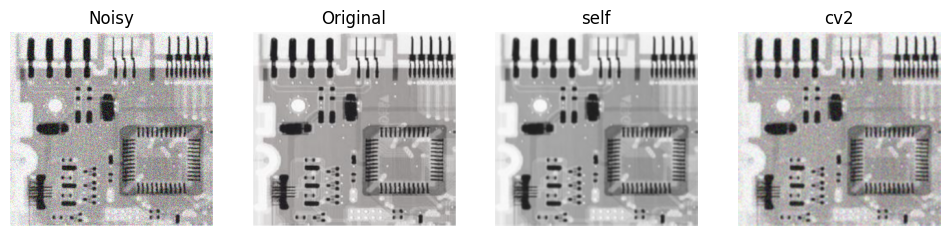

In [9]:
recon = arithmetic_mean_filter(noisy_image)
recon_cv = cv2.blur(noisy_image, (3, 3))

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 5))
axes[0].imshow(noisy_image)
axes[0].set_title("Noisy")
axes[0].axis("off")
axes[1].imshow(img)
axes[1].set_title("Original")
axes[1].axis("off")
axes[2].imshow(recon)
axes[2].set_title("self")
axes[2].axis("off")
axes[3].imshow(recon_cv)
axes[3].set_title("cv2")
axes[3].axis("off")
plt.show()

In [10]:
img.shape

(284, 296, 3)

In [11]:
def geometric_mean_filter(image, kernel=3):
    pad = kernel // 2
    padded = np.pad(img, pad, mode='reflect')
    output = np.zeros_like(img, dtype=np.float32)
    H, W, C = image.shape
    for i in range(H):
        for j in range(W):
            region = padded[i:i + kernel, j:j + kernel]
            
            region = np.where(region == 0, 1e-6, region)
            log_region = np.log(region)
            mean_log = np.mean(log_region)
            output[i, j] = np.exp(mean_log)
    return output

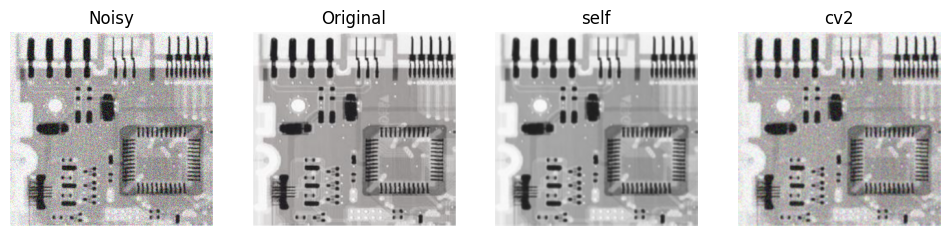

In [12]:
recon = geometric_mean_filter(noisy_image)
recon_cv = cv2.GaussianBlur(noisy_image, (3, 3), 0)

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 5))
axes[0].imshow(noisy_image)
axes[0].set_title("Noisy")
axes[0].axis("off")
axes[1].imshow(img)
axes[1].set_title("Original")
axes[1].axis("off")
axes[2].imshow(recon)
axes[2].set_title("self")
axes[2].axis("off")
axes[3].imshow(recon_cv)
axes[3].set_title("cv2")
axes[3].axis("off")
plt.show()

In [13]:
def add_salt_pepper_noise(image, prob=0.05, salt=True, pepper=True):
    noisy = image.copy()
    if salt:
        salt_mask = np.random.rand(*image.shape) < (prob/2)
        noisy[salt_mask] = 255

    if pepper: 
        pepper_mask = np.random.rand(*image.shape) < (prob/2)
        noisy[pepper_mask] = 0
    return noisy

In [14]:
def median_filter(image, kernel):
    pad = kernel // 2
    padded = np.pad(image, pad, mode='reflect')
    output = np.zeros_like(image)

    H, W, C = image.shape
    for i in range(H):
        for j in range(W):
            region = padded[i:i+kernel, j:j+kernel]
            output[i, j] = np.median(region)
    
    return output

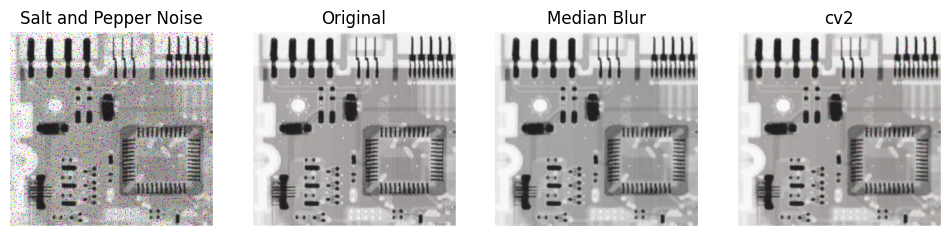

In [15]:
noisy_image = add_salt_pepper_noise(img)
recon = median_filter(noisy_image, 3)
noisy_image = (noisy_image * 255).astype('uint8')
recon_cv = cv2.medianBlur(noisy_image, 3)

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 5))
axes[0].imshow(noisy_image)
axes[0].set_title("Salt and Pepper Noise")
axes[0].axis("off")
axes[1].imshow(img)
axes[1].set_title("Original")
axes[1].axis("off")
axes[2].imshow(recon)
axes[2].set_title("Median Blur")
axes[2].axis("off")
axes[3].imshow(recon_cv)
axes[3].set_title("cv2")
axes[3].axis("off")
plt.show()

In [16]:
def max_filter(image, kernel):
    pad = kernel // 2
    padded = np.pad(image, pad, mode='reflect')
    output = np.zeros_like(image)

    H, W, C = image.shape
    for i in range(H):
        for j in range(W):
            region = padded[i:i+kernel, j:j+kernel]
            output[i, j] = np.max(region)
    
    return output

def min_filter(image, kernel):
    pad = kernel // 2
    padded = np.pad(image, pad, mode='reflect')
    output = np.zeros_like(image)

    H, W, C = image.shape
    for i in range(H):
        for j in range(W):
            region = padded[i:i+kernel, j:j+kernel]
            output[i, j] = np.min(region)
    
    return output

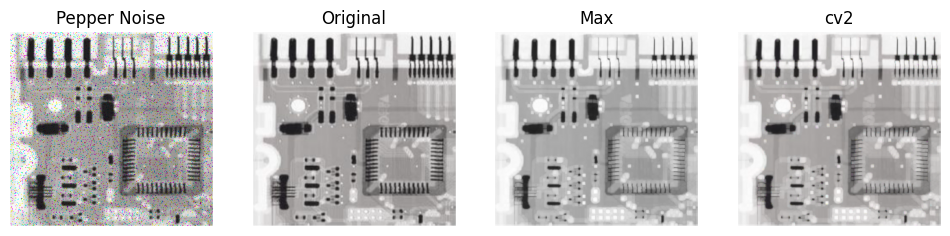

In [17]:
noisy_image = add_salt_pepper_noise(img, prob=0.1, salt=False)
recon = max_filter(noisy_image, 3)
# noisy_image = (noisy_image * 255).astype('uint8')
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
recon_cv = cv2.dilate(noisy_image, kernel)

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 5))
axes[0].imshow(noisy_image)
axes[0].set_title("Pepper Noise")
axes[0].axis("off")
axes[1].imshow(img)
axes[1].set_title("Original")
axes[1].axis("off")
axes[2].imshow(recon)
axes[2].set_title("Max")
axes[2].axis("off")
axes[3].imshow(recon_cv)
axes[3].set_title("cv2")
axes[3].axis("off")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.08627450980392157..255.0].


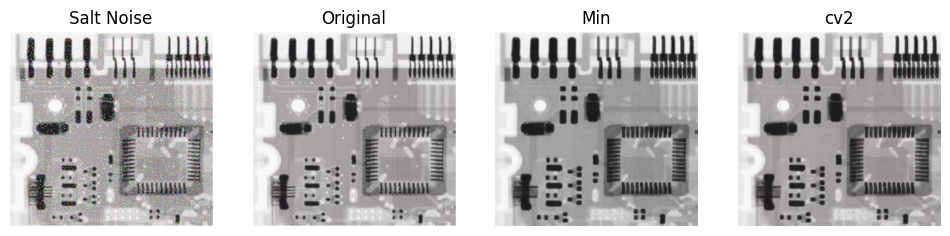

In [18]:
noisy_image = add_salt_pepper_noise(img, prob=0.1, pepper=False)
recon = min_filter(noisy_image, 3)
# noisy_image = (noisy_image * 255).astype('uint8')
kernel = np.ones((3, 3), np.uint8)
recon_cv = cv2.erode(noisy_image, kernel, iterations=1)

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 5))
axes[0].imshow(noisy_image)
axes[0].set_title("Salt Noise")
axes[0].axis("off")
axes[1].imshow(img)
axes[1].set_title("Original")
axes[1].axis("off")
axes[2].imshow(recon)
axes[2].set_title("Min")
axes[2].axis("off")
axes[3].imshow(recon_cv)
axes[3].set_title("cv2")
axes[3].axis("off")
plt.show()

In [56]:
def adaptive_gaussian_noise(img, k=0.5, win=5):
    if img.max() <= 1.0:
        img = img * 255
    img = img.astype(np.float32)
    mean = cv2.blur(img, (win, win))
    sq_mean = cv2.blur(img**2, (win, win))
    var = sq_mean - mean**2
    # sigma = 25 + k * np.sqrt(var)
    sigma = 40
    noise = np.random.normal(0, sigma, img.shape)
    noisy = img + noise
    # print(noisy)

    return np.clip(noisy, 0, 255).astype(np.uint8)

In [65]:
def adaptive_filter(img, k, noise_var):
    pad = k // 2
    padded = np.pad(img, pad, mode='reflect')
    out = np.zeros_like(img, dtype=np.float32)
    H, W, C = img.shape
    for i in range(H):
        for j in range(W):
            region = padded[i:i+k, j:j+k]
            for c in range(C):
                local_mean = np.mean(region[:, :, c])
                local_var = np.var(region[:, :, c])
                ratio = noise_var / (local_var + 1e-6)
                ratio = min(ratio, 0.8)
                if local_var == 0:
                    out[i, j, c] = local_mean
                else:
                    out[i, j, c] = img[i, j, c] - (ratio) * (img[i, j, c] - local_mean)
    return np.clip(out, 0, 255).astype(np.uint8)

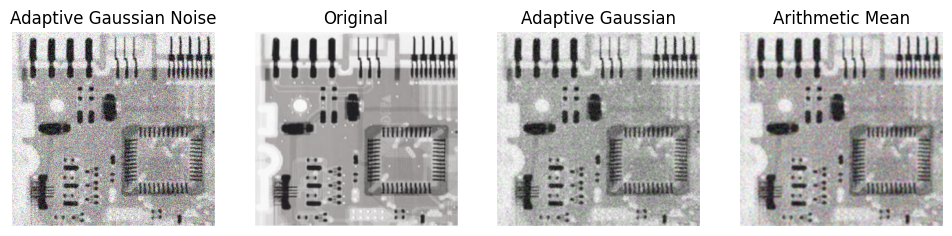

In [66]:
noisy_image = adaptive_gaussian_noise(img)
# noise_var = np.var(noisy_image.astype(np.float32) - cv2.GaussianBlur(noisy_image.astype(np.float32), (3, 3), 0))
noise_var = 40 * 40
recon = adaptive_filter(noisy_image, 3, noise_var)
recon_cv = cv2.blur(noisy_image, (3, 3))

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 5))
axes[0].imshow(noisy_image)
axes[0].set_title("Adaptive Gaussian Noise")
axes[0].axis("off")
axes[1].imshow(img)
axes[1].set_title("Original")
axes[1].axis("off")
axes[2].imshow(recon)
axes[2].set_title("Adaptive Gaussian")
axes[2].axis("off")
axes[3].imshow(recon_cv)
axes[3].set_title("Arithmetic Mean")
axes[3].axis("off")
plt.show()

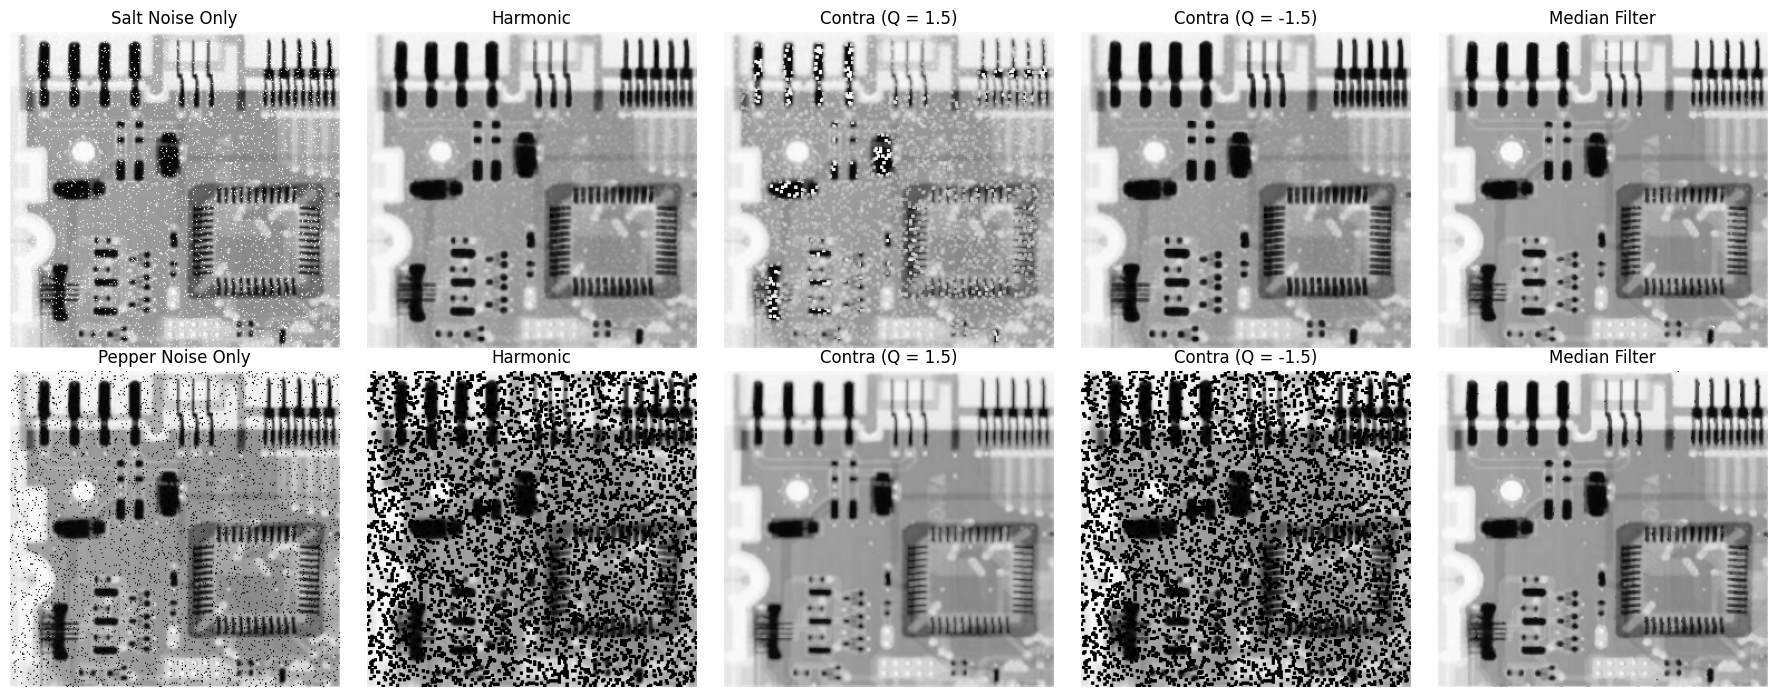

In [72]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ==========================================
# 1. NOISE & FILTER FUNCTIONS
# ==========================================

def add_salt_pepper_noise(image, prob=0.05, salt=True, pepper=True):
    """Injects independent salt and/or pepper noise."""
    noisy = image.copy()
    if salt:
        salt_mask = np.random.rand(*image.shape) < (prob/2)
        noisy[salt_mask] = 255
    if pepper: 
        pepper_mask = np.random.rand(*image.shape) < (prob/2)
        noisy[pepper_mask] = 0
    return noisy

def harmonic_mean_filter(img, k=3):
    """Removes salt noise, but smears pepper noise."""
    img_float = img.astype(np.float32) + 1e-6
    inverse_avg = cv2.blur(1.0 / img_float, (k, k))
    out = 1.0 / inverse_avg
    return np.clip(out, 0, 255).astype(np.uint8)

def contraharmonic_mean_filter(img, k=3, Q=1.5):
    """
    Q > 0 removes pepper noise.
    Q < 0 removes salt noise.
    """
    img_float = img.astype(np.float32) + 1e-6 
    numerator = cv2.blur(img_float**(Q + 1), (k, k))
    denominator = cv2.blur(img_float**Q, (k, k))
    out = numerator / (denominator + 1e-6)
    return np.clip(out, 0, 255).astype(np.uint8)


# ==========================================
# 2. EXECUTION PIPELINE
# ==========================================

# NOTE: Load your image here before running!
# img = plt.imread('your_circuit_board_image.jpg') 
# OR
# img = cv2.imread('your_circuit_board_image.jpg')

# --- THE SANITIZER BLOCK ---
# 0. Fix the CV_64F Error: Force the array to 32-bit float so OpenCV can read it
img = img.astype(np.float32)

# 1. Force to Grayscale (kills the "confetti" bug)
if len(img.shape) > 2:
    if img.shape[2] == 4: # Drop alpha channel if PNG
        img = img[:, :, :3]
    # Assuming RGB from matplotlib, use BGR2GRAY if using cv2.imread
    img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) 

# 2. Force to 0-255 uint8 (kills the "blackout" bug)
img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
# ---------------------------

# Generate Isolated Noise Images (5% density)
salt_img = add_salt_pepper_noise(img, prob=0.1, salt=True, pepper=False)
pepper_img = add_salt_pepper_noise(img, prob=0.1, salt=False, pepper=True)

# Process Salt Image
salt_harmonic = harmonic_mean_filter(salt_img, k=3)
salt_contra_pos = contraharmonic_mean_filter(salt_img, k=3, Q=1.5)
salt_contra_neg = contraharmonic_mean_filter(salt_img, k=3, Q=-1.5)
salt_median = cv2.medianBlur(salt_img, 3) # The ultimate fix

# Process Pepper Image
pepper_harmonic = harmonic_mean_filter(pepper_img, k=3)
pepper_contra_pos = contraharmonic_mean_filter(pepper_img, k=3, Q=1.5)
pepper_contra_neg = contraharmonic_mean_filter(pepper_img, k=3, Q=-1.5)
pepper_median = cv2.medianBlur(pepper_img, 3) # The ultimate fix


# ==========================================
# 3. PLOTTING
# ==========================================

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(18, 7))

# Helper function to clean up subplot code
def format_ax(ax, image, title):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

# ROW 1: SALT NOISE
format_ax(axes[0, 0], salt_img, "Salt Noise Only")
format_ax(axes[0, 1], salt_harmonic, "Harmonic")
format_ax(axes[0, 2], salt_contra_pos, "Contra (Q = 1.5)")
format_ax(axes[0, 3], salt_contra_neg, "Contra (Q = -1.5)")
format_ax(axes[0, 4], salt_median, "Median Filter")

# ROW 2: PEPPER NOISE
format_ax(axes[1, 0], pepper_img, "Pepper Noise Only")
format_ax(axes[1, 1], pepper_harmonic, "Harmonic")
format_ax(axes[1, 2], pepper_contra_pos, "Contra (Q = 1.5)")
format_ax(axes[1, 3], pepper_contra_neg, "Contra (Q = -1.5)")
format_ax(axes[1, 4], pepper_median, "Median Filter")

plt.tight_layout()
plt.show()